# Introduzione alle equazioni differenziali e ai problemi di Cauchy


## Obiettivi didattici

Al termine del notebook saremo in grado di:

- riconoscere un'equazione differenziale ordinaria e il suo ordine;
- formulare un problema di Cauchy;
- comprendere il ruolo del dato iniziale;
- derivare e implementare il metodo di Eulero esplicito;
- valutare sperimentalmente l'errore e l'ordine di convergenza;
- riconoscere l'effetto del passo sulla stabilità numerica.

### Perché studiare le equazioni differenziali?

Molti fenomeni vengono descritti più naturalmente specificando **come una quantità varia** anziché fornendo direttamente il suo valore. Se $y(t)$ indica una grandezza dipendente dal tempo, la derivata $y'(t)$ ne rappresenta il tasso di variazione.

Esempi:

- crescita di una popolazione o diffusione di un'epidemia;
- decadimento di una sostanza;
- moto di un corpo;
- evoluzione di temperatura o concentrazione;
- dinamiche continue usate in modelli per l'analisi dei dati, come i *neural ODE*.

Un'equazione che lega una funzione incognita alle sue derivate è detta **equazione differenziale**.

### Equazioni differenziali ordinarie

Un'**equazione differenziale ordinaria** (ODE, *Ordinary Differential Equation*) contiene derivate rispetto a una sola variabile indipendente.

L'**ordine** dell'equazione è l'ordine massimo delle derivate presenti. Per esempio:

$$y'(t)=-2y(t)$$

è un'ODE del primo ordine, mentre

$$y''(t)+3y'(t)+2y(t)=0$$

è un'ODE del secondo ordine. In questo notebook consideriamo soprattutto equazioni del primo ordine scritte nella forma

$$y'(t)=f(t,y(t)).$$

La funzione $f$ descrive la legge di evoluzione del sistema.

*Una famiglia di soluzioni*

Consideriamo

$$y'(t)=-2y(t).$$

Tutte le funzioni

$$y(t)=C e^{-2t}, \qquad C\in\mathbb{R},$$

soddisfano l'equazione. L'equazione differenziale, da sola, non determina quindi un'unica soluzione: occorre un'informazione aggiuntiva.

### Il problema di Cauchy

Un **problema di Cauchy** per un'ODE del primo ordine consiste nel trovare una funzione $y(t)$ tale che

$$
\begin{cases}
y'(t)=f(t,y(t)), & t\in[t_0,T],\\
y(t_0)=y_0.
\end{cases}
$$

Il valore $y_0$ è il **dato iniziale**. Geometricamente, stiamo cercando la curva integrale che passa per il punto $(t_0,y_0)$ e la cui pendenza in ogni punto è assegnata da $f(t,y)$.

Nell'esempio $y'=-2y$, imponendo $y(0)=1$ si ottiene $C=1$ e quindi

$$y(t)=e^{-2t}.$$

*Esistenza e unicità: idea essenziale*

Prima di approssimare una soluzione è naturale chiedersi se essa esista e sia unica. Una versione semplificata del teorema di **Cauchy–Lipschitz** afferma che, vicino a $(t_0,y_0)$:

- se $f(t,y)$ è continua, esiste almeno una soluzione locale;
- se inoltre $f$ è lipschitziana rispetto a $y$, la soluzione locale è unica.

La condizione di Lipschitz richiede che esista $L>0$ tale che

$$|f(t,y_1)-f(t,y_2)|\leq L|y_1-y_2|.$$

Se $\partial f/\partial y$ è continua e limitata in una regione, allora in quella regione la condizione è soddisfatta. Per esempio, $f(t,y)=-2y$ è lipschitziana rispetto a $y$ con $L=2$.

> **Nota.** Queste condizioni sono sufficienti, non necessarie. In questo corso ci concentreremo sulla costruzione e sull'analisi dei metodi numerici.

### Dalla soluzione continua ai valori numerici

In generale non è possibile esprimere la soluzione di un problema di Cauchy mediante una formula chiusa. Cerchiamo allora approssimazioni in un insieme discreto di istanti.

Dividiamo $[t_0,T]$ in $N$ sottointervalli di ampiezza costante

$$h=\frac{T-t_0}{N}, \qquad t_n=t_0+nh, \quad n=0,\ldots,N.$$

Indichiamo con $y_n$ un'approssimazione del valore esatto $y(t_n)$. Il numero $h$ è detto **passo di discretizzazione**.

### Il metodo di Eulero esplicito

Dalla definizione di derivata, per $h$ piccolo,

$$y'(t_n)\approx\frac{y(t_{n+1})-y(t_n)}{h}.$$

Poiché l'equazione impone $y'(t_n)=f(t_n,y(t_n))$, otteniamo

$$\frac{y(t_{n+1})-y(t_n)}{h}\approx f(t_n,y(t_n)).$$

Sostituendo i valori esatti con le approssimazioni numeriche segue la formula di Eulero:

$$\boxed{y_{n+1}=y_n+h f(t_n,y_n)}, \qquad y_0\text{ assegnato}.$$

Il metodo è **esplicito** perché $y_{n+1}$ si calcola direttamente usando quantità già note. Geometricamente, a ogni passo si prosegue lungo la retta tangente determinata dalla pendenza $f(t_n,y_n)$.

### Algoritmo

**Input:** funzione $f$, estremi $t_0,T$, dato iniziale $y_0$, numero di passi $N$.

1. Calcola $h=(T-t_0)/N$.
2. Poni $t_0$ e $y_0$ come valori iniziali.
3. Per $n=0,\ldots,N-1$, calcola $y_{n+1}=y_n+h f(t_n,y_n)$.
4. Restituisci i nodi $t_n$ e le approssimazioni $y_n$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def eulero_esplicito(f, intervallo, y0, N):
    """
    Approssima y' = f(t, y), y(t0) = y0, con Eulero esplicito.

    Parametri
    ---------
    f          : funzione f(t, y)
    intervallo : coppia (t0, T)
    y0         : dato iniziale scalare o vettoriale
    N          : numero di passi
    """
    t0, T = intervallo
    t = np.linspace(t0, T, N + 1)
    h = (T - t0) / N

    y0_array = np.asarray(y0, dtype=float)
    y = np.zeros((N + 1,) + y0_array.shape)
    y[0] = y0_array

    for n in range(N):
        y[n + 1] = y[n] + h * np.asarray(f(t[n], y[n]))

    return t, y

 *Esempio 1*
 
Consideriamo il problema

$$
\begin{cases}
y'(t)=-2y(t),\\
y(0)=1,
\end{cases}
\qquad t\in[0,2].
$$

La soluzione esatta è $y(t)=e^{-2t}$. Applichiamo Eulero con $N=10$, dunque $h=0.2$. Il primo passo è

$$y_1=y_0+h(-2y_0)=1+0.2(-2)=0.6.$$

In [3]:
f = lambda t, y: -2 * y
soluzione_esatta = lambda t: np.exp(-2 * t)

t, y_eulero = eulero_esplicito(f, (0, 2), y0=1.0, N=10)
y_esatta = soluzione_esatta(t)

print(f'Passo h = {t[1] - t[0]:.2f}')
print('  n      t_n       Eulero       Esatta        Errore')
for n, (tn, yn, ye) in enumerate(zip(t, y_eulero, y_esatta)):
    print(f'{n:3d}   {tn:6.2f}   {yn:10.6f}   {ye:10.6f}   {abs(yn-ye):10.2e}')

Passo h = 0.20
  n      t_n       Eulero       Esatta        Errore
  0     0.00     1.000000     1.000000     0.00e+00
  1     0.20     0.600000     0.670320     7.03e-02
  2     0.40     0.360000     0.449329     8.93e-02
  3     0.60     0.216000     0.301194     8.52e-02
  4     0.80     0.129600     0.201897     7.23e-02
  5     1.00     0.077760     0.135335     5.76e-02
  6     1.20     0.046656     0.090718     4.41e-02
  7     1.40     0.027994     0.060810     3.28e-02
  8     1.60     0.016796     0.040762     2.40e-02
  9     1.80     0.010078     0.027324     1.72e-02
 10     2.00     0.006047     0.018316     1.23e-02


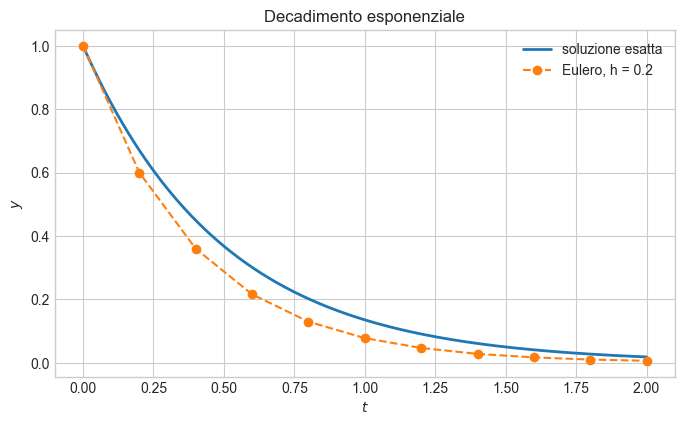

In [4]:
t_fine = np.linspace(0, 2, 400)

plt.figure(figsize=(8, 4.5))
plt.plot(t_fine, soluzione_esatta(t_fine), label='soluzione esatta', linewidth=2)
plt.plot(t, y_eulero, 'o--', label='Eulero, h = 0.2')
plt.xlabel('$t$')
plt.ylabel('$y$')
plt.title('Decadimento esponenziale')
plt.legend()
plt.show()

### Errore e convergenza

L'**errore globale** al nodo $t_n$ è

$$e_n=y(t_n)-y_n.$$

Per misurare l'errore sull'intero intervallo usiamo, per esempio,

$$E_h=\max_{0\leq n\leq N}|e_n|.$$

Sotto opportune ipotesi di regolarità, il metodo di Eulero è di **ordine uno**:

$$E_h=O(h).$$

Quindi, dimezzando $h$, ci aspettiamo che l'errore globale si dimezzi circa. Verifichiamolo numericamente.

In [5]:
numeri_passi = np.array([5, 10, 20, 40, 80, 160])
passi = 2.0 / numeri_passi
errori = []

for N in numeri_passi:
    t_num, y_num = eulero_esplicito(f, (0, 2), y0=1.0, N=N)
    errore = np.max(np.abs(soluzione_esatta(t_num) - y_num))
    errori.append(errore)

errori = np.array(errori)
ordini = np.log2(errori[:-1] / errori[1:])

print('    h          errore massimo    ordine stimato')
print(f'{passi[0]:8.5f}      {errori[0]:10.3e}          -')
for h, err, p in zip(passi[1:], errori[1:], ordini):
    print(f'{h:8.5f}      {err:10.3e}        {p:5.3f}')

    h          errore massimo    ordine stimato
 0.40000       2.493e-01          -
 0.20000       8.933e-02        1.481
 0.10000       4.020e-02        1.152
 0.05000       1.920e-02        1.066
 0.02500       9.394e-03        1.031
 0.01250       4.647e-03        1.015


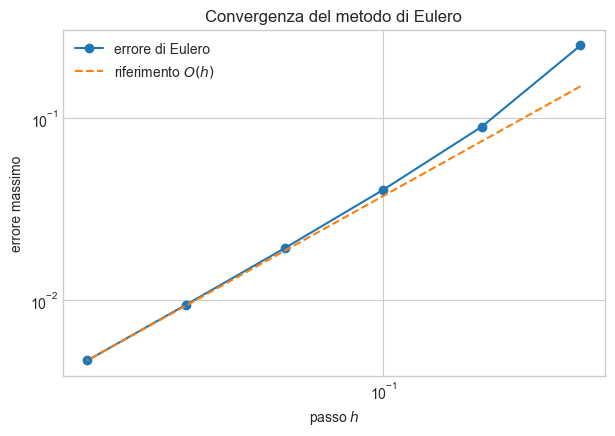

In [6]:
plt.figure(figsize=(7, 4.5))
plt.loglog(passi, errori, 'o-', label='errore di Eulero')
plt.loglog(passi, errori[-1] * passi / passi[-1], '--', label='riferimento $O(h)$')
plt.xlabel('passo $h$')
plt.ylabel('errore massimo')
plt.title('Convergenza del metodo di Eulero')
plt.legend()
plt.show()

### Il passo e la stabilità numerica

Un passo piccolo non serve soltanto a migliorare l'accuratezza: può essere necessario per evitare comportamenti numerici non fisici. Consideriamo l'equazione test

$$y'=\lambda y, \qquad \lambda<0.$$

La soluzione esatta decade verso zero. Eulero produce invece

$$y_{n+1}=(1+h\lambda)y_n,$$

e quindi $y_n=(1+h\lambda)^n y_0$. Affinché anche la soluzione numerica decada, deve valere

$$|1+h\lambda|<1.$$

Per $\lambda=-10$ la condizione diventa $0<h<0.2$. Se scegliamo $h=0.25$, il fattore di amplificazione è $-1.5$: la soluzione numerica oscilla e cresce, anche se quella esatta tende a zero.

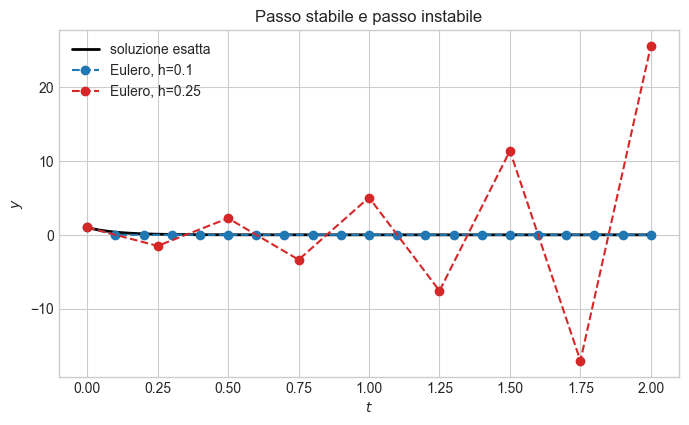

In [7]:
f_stiff = lambda t, y: -10 * y
t_esatto = np.linspace(0, 2, 500)

plt.figure(figsize=(8, 4.5))
plt.plot(t_esatto, np.exp(-10 * t_esatto), 'k', linewidth=2, label='soluzione esatta')

for N, colore in [(20, 'C0'), (8, 'C3')]:
    t_num, y_num = eulero_esplicito(f_stiff, (0, 2), 1.0, N)
    h = 2 / N
    plt.plot(t_num, y_num, 'o--', color=colore, label=f'Eulero, h={h:g}')

plt.xlabel('$t$')
plt.ylabel('$y$')
plt.title('Passo stabile e passo instabile')
plt.legend()
plt.show()

*Esempio 2*

Un modello più realistico della crescita esponenziale tiene conto di una capacità massima $K$ dell'ambiente:

$$
\begin{cases}
P'(t)=rP(t)\left(1-\dfrac{P(t)}{K}\right),\\
P(0)=P_0.
\end{cases}
$$

$P(t)$ può rappresentare una popolazione o, più in generale, una quantità che inizialmente cresce e poi satura. Il parametro $r>0$ è il tasso di crescita e $K>0$ è la capacità portante.

La soluzione esatta, utile per il confronto, è

$$P(t)=\frac{K}{1+\left(\frac{K-P_0}{P_0}\right)e^{-rt}}.$$

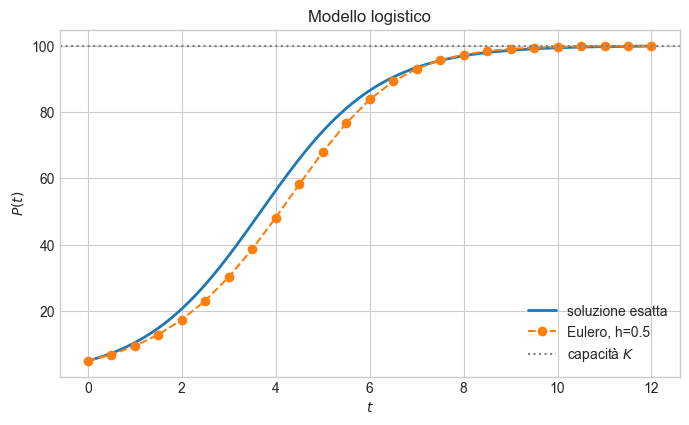

In [8]:
r, K, P0 = 0.8, 100.0, 5.0
f_logistica = lambda t, P: r * P * (1 - P / K)
P_esatta = lambda t: K / (1 + ((K - P0) / P0) * np.exp(-r * t))

t, P_eulero = eulero_esplicito(f_logistica, (0, 12), P0, N=24)
t_fine = np.linspace(0, 12, 400)

plt.figure(figsize=(8, 4.5))
plt.plot(t_fine, P_esatta(t_fine), linewidth=2, label='soluzione esatta')
plt.plot(t, P_eulero, 'o--', label='Eulero, h=0.5')
plt.axhline(K, color='gray', linestyle=':', label='capacità $K$')
plt.xlabel('$t$')
plt.ylabel('$P(t)$')
plt.title('Modello logistico')
plt.legend()
plt.show()

### Sistemi di equazioni differenziali

Le stesse idee valgono quando l'incognita è un vettore $\mathbf y(t)\in\mathbb{R}^m$:

$$\mathbf y'(t)=\mathbf f(t,\mathbf y(t)), \qquad \mathbf y(t_0)=\mathbf y_0.$$

Eulero si scrive senza modifiche sostanziali:

$$\mathbf y_{n+1}=\mathbf y_n+h\mathbf f(t_n,\mathbf y_n).$$

Per esempio, l'equazione del secondo ordine $x''+\gamma x'+\omega^2x=0$ può essere trasformata nel sistema del primo ordine

$$
\begin{cases}
x'=v,\\
v'=-\omega^2x-\gamma v.
\end{cases}
$$

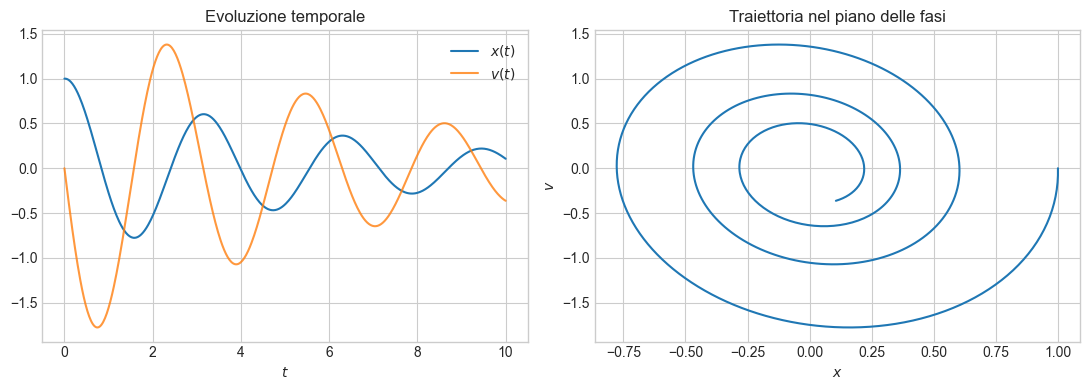

In [9]:
omega, gamma = 2.0, 0.4

def oscillatore_smorzato(t, stato):
    x, v = stato
    return np.array([v, -omega**2 * x - gamma * v])

t, stato = eulero_esplicito(oscillatore_smorzato, (0, 10), y0=[1, 0], N=500)
x, v = stato[:, 0], stato[:, 1]

fig, assi = plt.subplots(1, 2, figsize=(11, 4))
assi[0].plot(t, x, label='$x(t)$')
assi[0].plot(t, v, label='$v(t)$', alpha=0.8)
assi[0].set_xlabel('$t$')
assi[0].set_title('Evoluzione temporale')
assi[0].legend()

assi[1].plot(x, v)
assi[1].set_xlabel('$x$')
assi[1].set_ylabel('$v$')
assi[1].set_title('Traiettoria nel piano delle fasi')
plt.tight_layout()
plt.show()

 *Costo e limiti del metodo*

Con $N$ passi, Eulero richiede $N$ valutazioni della funzione $f$, quindi il costo cresce linearmente con $N$. Il metodo è semplice e utile per comprendere i concetti fondamentali, ma presenta alcuni limiti:

- ha ordine di convergenza soltanto uno;
- può richiedere passi molto piccoli;
- può diventare instabile per problemi rigidi (*stiff*);
- non conserva necessariamente proprietà qualitative della soluzione, come positività o energia.

Metodi più accurati, come Heun e Runge–Kutta, saranno costruiti a partire dalle stesse idee.

**Esercizi**

 *Esercizio 1* — Calcolo manuale*
Per il problema $y'=y-t$, $y(0)=1$, calcolare a mano i primi tre passi di Eulero con $h=0.1$.

*Esercizio 2 — *Confronto con la soluzione esatta*
Applicare Eulero a $y'=3y$, $y(0)=2$ nell'intervallo $[0,1]$. Confrontare con $y(t)=2e^{3t}$ usando $N=10,20,40$. Che cosa accade all'errore quando $N$ raddoppia?

*Esercizio 3 — Stabilità*
Per $y'=-20y$, determinare teoricamente l'intervallo di valori di $h$ per cui Eulero è stabile. Verificare numericamente con due passi: uno interno e uno esterno all'intervallo.

*Esercizio 4 — Dati e modello logistico*
Modificare $r$, $K$ e $P_0$ nell'esempio logistico. Descrivere separatamente l'effetto di ciascun parametro sulla curva.

*Esercizio 5 — Sistema*
Nel modello dell'oscillatore, porre $\gamma=0$. Ripetere l'esperimento con diversi valori di $h$ e osservare se l'ampiezza numerica rimane costante.

## Riepilogo

- Un problema di Cauchy combina un'ODE con un dato iniziale.
- Il metodo di Eulero sostituisce localmente la soluzione con la sua retta tangente.
- La ricorrenza è $y_{n+1}=y_n+h f(t_n,y_n)$.
- Eulero è un metodo di ordine uno: l'errore globale è proporzionale a $h$.
- La scelta del passo influenza sia l'accuratezza sia la stabilità.
- La formulazione si estende direttamente ai sistemi di ODE.